In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error,r2_score
import pandas as pnd


<h1 style="color: red;">Section 1: Data</h1>

<h2>1) Préparation de données</h2>

In [2]:
np.random.seed(44) #à chaque exécution,générer le même dataset de manière aléatoire
# Coefficients
a1, a2, b = 2, 3, 5  # y = 2*X1 + 3*X2 + 5 + bruit
nombre_points = 100 # Nombre de points
# Génération des deux features (X1 et X2)
X1 = np.random.rand(nombre_points) * 10
X2 = np.random.rand(nombre_points) * 10
# Empilement des features dans une seule matrice (shape: (100, 2))
X = np.column_stack((X1, X2))
# Génération du bruit
bruit = np.random.randn(nombre_points) * 2  # Bruit
# Calcul de la target
y = a1 * X1 + a2 * X2 + b + bruit

#spilt data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=23)

**Importance du decoupage en training et testing set**

Le training set sert à entraîner les paramètres du modèle. Le test set sert à évaluer sa capacité de généralisation sur des données jamais vues auparavant. Cette séparation permet d’éviter le problème d’overfitting (surapprentissage) et la surestimation des performances du modèle.

<h1 style="color: red;">Section 2: Neural network avec tensorflow</h1>

In [3]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

<h2>2) Modèle de réseau de neurones</h2>

* `X1`et `X2` représentent les deux entrées (inputs).
* `y` représente la sortie (output).
* La fonction d’activation est `linéaire`, puisque l’on modélise une régression linéaire.



In [28]:
model_nn = Sequential([tf.keras.Input(shape=(2,))]) #compéter
output_layer=Dense(1,activation='linear') #compéter
model_nn.add(output_layer)
model_nn.compile(optimizer='adam',
              loss='MSE',
              metrics=['MSE']) #compéter
model_nn.fit(X_train, y_train, epochs = 1000, verbose = 0) #compéter

In [29]:
model_nn.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (48.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8 (36.00 B)

**Role de `fit`**

La fonction `fit` est utilisée pour entraîner notre modèle. Pour chaque epoch, elle calcule les prédictions, l'erreur, puis met à jour les poids et le biais pour minimiser l’erreur.

=========================================================================

**Nombre des paramètre**

Notre modèle contient 3 paramètres
* 2 paramètre représentant les deux poids `W1` et `W2`.
* 1 paramètre représentant le bias `b`.

=========================================================================

**Pourquoi faire du tuning ?**

Il est important de faire du tuning (réglage des hyperparamètres) lorsqu’un modèle n’apprend pas correctement ou ne généralise pas bien.

Le tuning consiste à ajuster des éléments comme :
* learning rate,
* nombre d’epochs,
* batch size,
* nombre de neurones/couches,
* régularisation,
* type de fonction d’activation



<h2>3) Prédiction en utilisant le modèle</h2>

In [30]:
yhat_nn=model_nn.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


In [31]:
yhat_nn=yhat_nn.flatten()

In [32]:
W_nn, bias_nn = model_nn.layers[0].get_weights()

# Afficher les poids et biais
print("Poids :", W_nn.flatten())
print("Biais :", bias_nn)

Poids : [2.3474505 1.7295268]
Biais : [2.2908316]


**Prédiction manuelle**

In [33]:
yhat_man = (X_test @ W_nn + bias_nn).flatten()
print("Predictions manuelles :", yhat_man[:5])
print("Predictions identiques a predict :", np.allclose(yhat_nn, yhat_man))



Predictions manuelles : [33.1980557  32.96310326 26.90038458 26.41823659 30.74410413]
Predictions identiques a predict : True


<h2>4) Evaluation du modèle</h2>

Train MSE: 57.955866669162084 Train R2: 0.25327045694617245
Test MSE: 57.955866669162084 Test R2: 0.25327045694617245


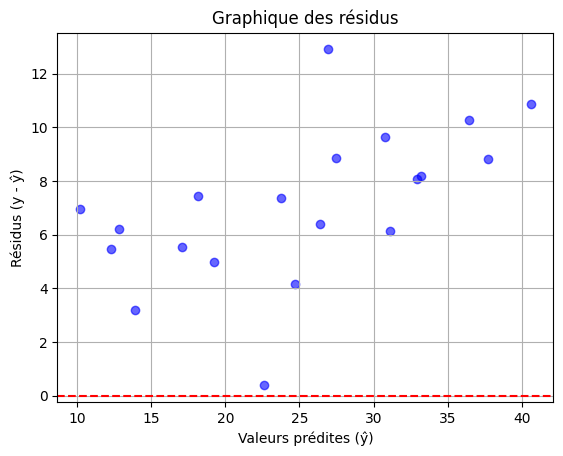

In [35]:
yhat_train_nn = model_nn.predict(X_train, verbose=0).flatten()

mse_nn_train,r2_nn_train=mean_squared_error(y_train,yhat_train_nn),r2_score(y_train,yhat_train_nn)
mse_nn_test,r2_nn_test=mean_squared_error(yhat_nn,y_test),r2_score(yhat_nn,y_test)

print("Train MSE:", mse_nn_test, "| Train R2:", r2_nn_test)
print("Test MSE:", mse_nn_test, "| Test R2:", r2_nn_test)

import matplotlib.pyplot as plt

# Tracé des résidus
plt.scatter(yhat_nn, y_test - yhat_nn, color='blue', alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valeurs prédites (ŷ)")
plt.ylabel("Résidus (y - ŷ)")
plt.title("Graphique des résidus")
plt.grid(True)
plt.show()


**Interprétation des résidus**

Les résidus permettent de vérifier si le modèle est adapté aux données. Lorsqu’ils sont dispersés de manière aléatoire autour de zéro, cela suggère que le modèle décrit correctement la relation entre les variables. À l’inverse, la présence d’un schéma ou d’une tendance dans les résidus peut révéler une mauvaise spécification du modèle ou l’existence d’une relation non linéaire.

**Pourquoi évaluer le modèle sur les ensembles d’entraînement et de test ?**

L’évaluation sur l’ensemble d’entraînement permet de mesurer dans quelle mesure le modèle s’ajuste aux données utilisées pour son apprentissage. L’évaluation sur l’ensemble de test permet d’apprécier ses performances sur de nouvelles données. Comparer les résultats obtenus sur ces deux ensembles est essentiel pour évaluer la capacité de généralisation du modèle et pour identifier d’éventuels problèmes de sous-apprentissage ou de surapprentissage.

<h1>From scratch</h1>


<h1 style="color: red;"> Section 3 :Régression linéaire from scratch </h1>


<h2>Modèle (version1) de régression linéaire from scratch avec utilisation des matrices</h2>


In [36]:
learning_rate = 0.0001
epochs = 1000

# Initialisation des paramètres
W = np.array([[0.0], [0.0]])  # Shape: (2, 1)
b = 0.0

# Reshape y_train pour garantir les dimensions adéquates
y_train_matrix = y_train.reshape(-1, 1)  # Shape: (n_samples, 1)
n = len(X_train)

# Entraînement (descente de gradient vectorisée)
for epoch in range(epochs):
    y_pred = X_train @ W + b  # Shape: (n, 1)
    error = y_pred - y_train_matrix  # Shape: (n, 1)

    # Calcul des gradients
    dW = (1 / n) * (X_train.T @ error)  # Shape: (2, 1)
    db = (1 / n) * np.sum(error)  # Scalaire

    # Mise à jour des paramètres
    W -= learning_rate * dW
    b -= learning_rate * db

print("Parametres ajustes:")
print(f"W =\n{W}")
print(f"b = {b:.4f}")

Parametres ajustes:
W =
[[2.55761346]
 [3.19975219]]
b = 0.5860


In [38]:
yhat_scratch = (X_test @ W + b).flatten()
print("Predictions scratch :", yhat_scratch[:5])


Predictions scratch : [42.36498965 44.03378077 37.3024472  29.12429648 41.93561724]


In [39]:
mse_scratch = mean_squared_error(y_test, yhat_scratch)
r2_scratch = r2_score(y_test, yhat_scratch)

print("Scratch - MSE:", mse_scratch, "R2:", r2_scratch)
print("Comparaison poids attendus ~ [2, 3] :", W.flatten())
print("Comparaison biais attendu ~ 5 :", b)



Scratch - MSE: 5.402510380571767 R2: 0.9520368718618744
Comparaison poids attendus ~ [2, 3] : [2.55761346 3.19975219]
Comparaison biais attendu ~ 5 : 0.5860413170449176
